# Credit Score Prediction Model (Decision Tree)

This Jupyter Notebook implements a Decision Tree Classifier to predict continuous credit scores (CIBIL score) and determine their categories (Poor, Average, Good).

In [1]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

import warnings 
warnings.filterwarnings('ignore')

## 1. Load Dataset

In [2]:
df = pd.read_csv("../Notebook/loan_approval_dataset_cleaned.csv")
print("Dataset Shape:", df.shape)

Dataset Shape: (4269, 8)


In [3]:
df.head()

,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,loan_status,assets_value
0,1,0,9600000,29900000,12,778,1,50700000
1,0,1,4100000,12200000,8,417,0,17000000
2,1,0,9100000,29700000,20,506,0,57700000
3,1,0,8200000,30700000,8,467,0,52700000
4,0,1,9800000,24200000,20,382,0,55000000


In [4]:
print("Null Values : ", df.isnull().sum())
print("Duplicate Values :", df.duplicated().sum())
print("Columns :", df.columns)
print("Shape :", df.shape)

Null Values :  education        0
self_employed    0
income_annum     0
loan_amount      0
loan_term        0
cibil_score      0
loan_status      0
assets_value     0
dtype: int64
Duplicate Values : 0
Columns : Index(['education', 'self_employed', 'income_annum', 'loan_amount',
       'loan_term', 'cibil_score', 'loan_status', 'assets_value'],
      dtype='object')
Shape : (4269, 8)


## 2. Visualization & Outliers

education , self_employed , income_annum , loan_amount , loan_term , cibil_score , loan_status , assets_value , 

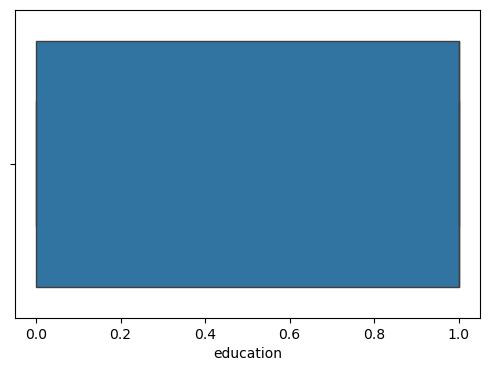

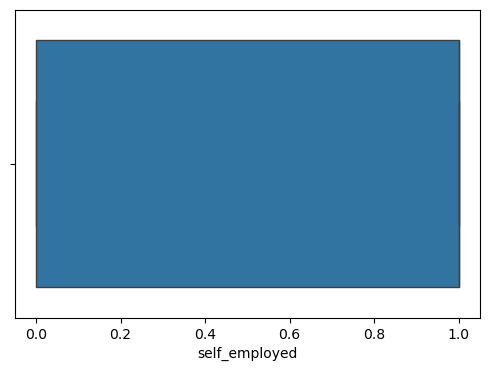

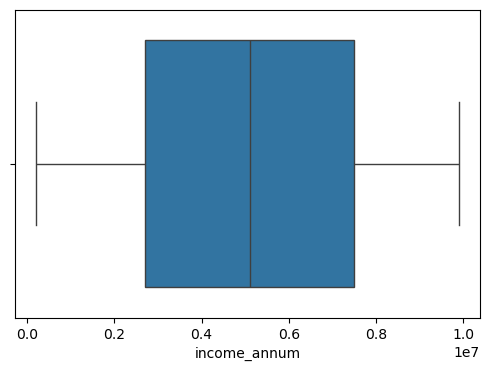

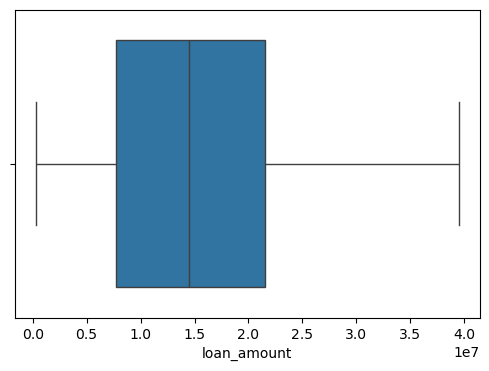

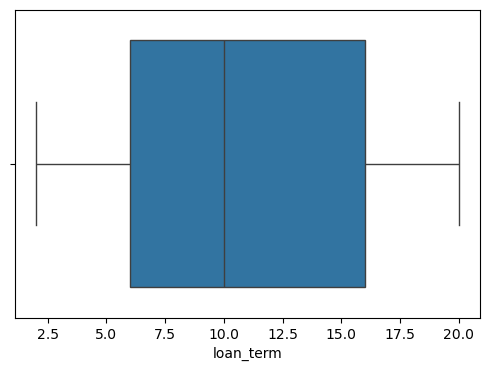

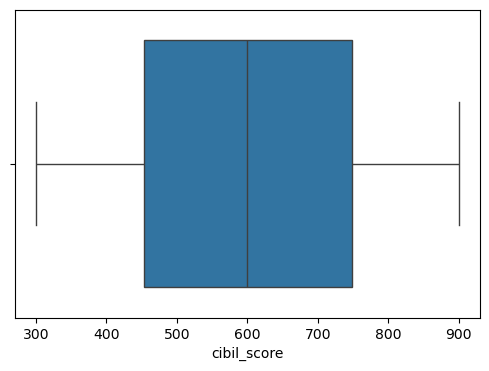

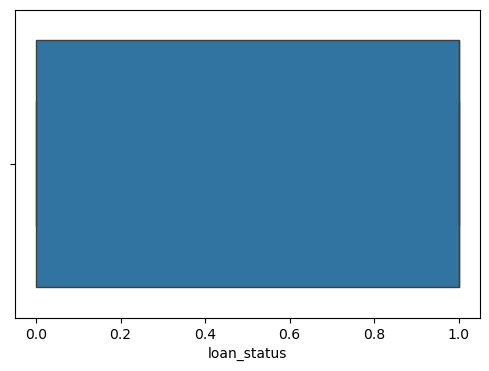

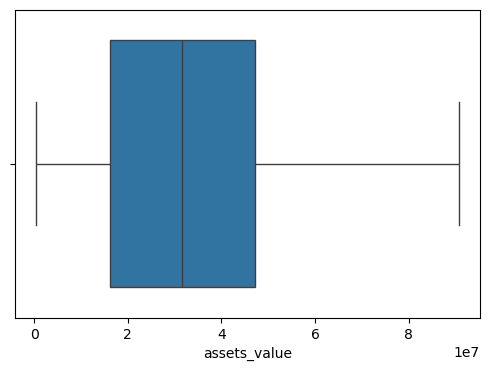

In [5]:
# Outliers
col = ['education', 'self_employed', 'income_annum', 'loan_amount', 'loan_term', 'cibil_score', 'loan_status', 'assets_value']
for i in col:
    print(i, end=" , ")
    plt.figure(figsize=(6,4))
    sns.boxplot(x=df[i])

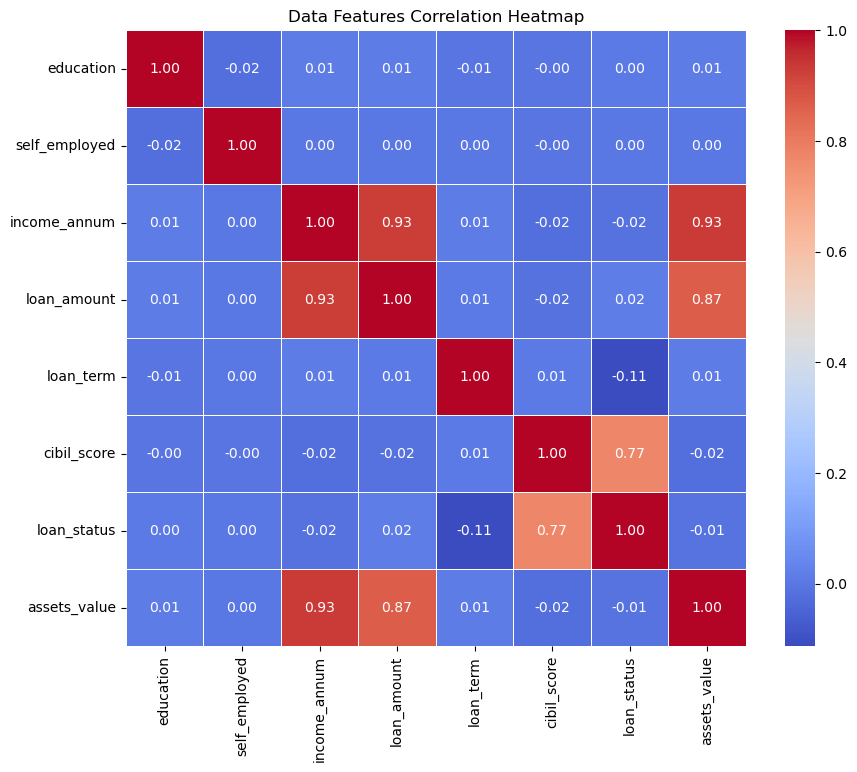

In [6]:
plt.figure(figsize=(10, 8))
# Heatmap plot karein
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Data Features Correlation Heatmap')
plt.show()

## 3. Model Training & Prediction

--------------------------------------------------
ENTER VALUES FOR PREDICTION:
--------------------------------------------------
Predicted Credit Score: 882
Decision (Credit Score Category): Good
--------------------------------------------------

Model Accuracy (Category-based): 100.0%


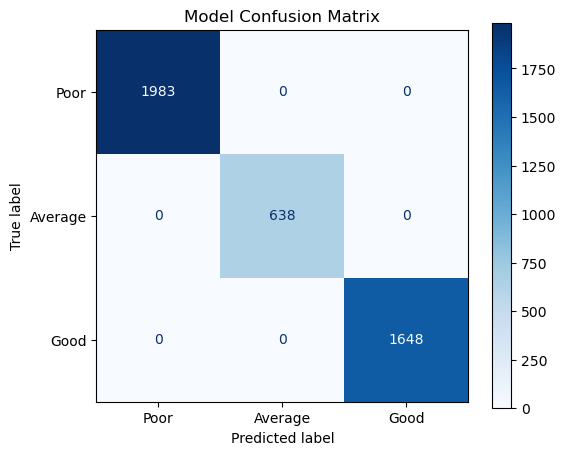

In [ ]:
# Feature Selection
features = ['education', 'self_employed', 'income_annum', 'loan_amount', 'loan_term', 'assets_value', 'loan_status']
X = df[features]
y = df['cibil_score']

# Fit DecisionTreeClassifier model
model = DecisionTreeClassifier(random_state=42)
model.fit(X, y)

# --- USER INPUT SECTION ---
print("-" * 50)
print("ENTER VALUES FOR PREDICTION:")
education = float(input("Enter Education (1 for Graduate, 0 for Not Graduate): "))
self_employed = float(input("Enter Self Employed (1 for Yes, 0 for No): "))
income = float(input("Enter Annual Income: "))
loan_amt = float(input("Enter Loan Amount: "))
loan_term = float(input("Enter Loan Term: "))
assets = float(input("Enter Total Assets Value: "))
loan_status = float(input("Enter Loan Status (1 for Approved, 0 for Rejected): "))

# Predict continuous credit score
pred_score = model.predict([[education, self_employed, income, loan_amt, loan_term, assets, loan_status]])[0]
print("-" * 50)
print("Predicted Credit Score:", round(pred_score, 2))

# Map predicted score to Good / Poor / Average category
if pred_score < 580:
    decision = 'Poor'
elif pred_score < 670:
    decision = 'Average'
else:
    decision = 'Good'
print("Decision (Credit Score Category):", decision)
print("-" * 50)

# Model Accuracy based on Category
def categorize_score(score):
    if score < 580:
        return 'Poor'
    elif score < 670:
        return 'Average'
    else:
        return 'Good'

y_actual_cat = y.apply(categorize_score)

# Predict on all data to evaluate
y_pred_continuous = model.predict(X)
y_pred_cat = pd.Series(y_pred_continuous).apply(categorize_score)

acc = accuracy_score(y_actual_cat, y_pred_cat) * 100
print(f"\nModel Accuracy (Category-based): {round(acc, 2)}%")

# Visuals (Confusion Matrix)
cm = confusion_matrix(y_actual_cat, y_pred_cat, labels=['Poor', 'Average', 'Good'])
plt.figure(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Poor', 'Average', 'Good'])
disp.plot(cmap='Blues', ax=plt.gca())
plt.title('Model Confusion Matrix')
plt.show()